# Analysis of Repeated Antibiotics

In [138]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
import os
import glob
import gzip
from matplotlib.ticker import PercentFormatter
%matplotlib inline

In [139]:
current_working_dir = os.getcwd()
print(current_working_dir)

c:\Users\m84300af\OneDrive - The University of Manchester\Documents\GitHub\amr-uom-brit


In [140]:
def makeFilePath(pathFromWorkspace, fileName):
    workingdir = "/workspace/" if (os.name != "nt") else ""
    filepath = workingdir+pathFromWorkspace+fileName

    return filepath

In [141]:
# input_file_path = makeFilePath("output/measures/", "input_all.csv")
# data = pd.read_csv(input_file_path)
# data.head()

In [142]:
input_20190101_file_path = makeFilePath("output/measures/", "input_2019-01-01.csv.gz")
data201901 = pd.read_csv(input_20190101_file_path, compression='gzip')
data201901['date'] = '2019-01-01'

In [143]:
input_20190201_file_path = makeFilePath("output/measures/", "input_2019-02-01.csv.gz")
data201902 = pd.read_csv(input_20190201_file_path, compression='gzip')
data201902['date'] = '2019-02-01'
data201902 = data201901.append(data201902, ignore_index=True)

In [144]:
input_20190301_file_path = makeFilePath("output/measures/", "input_2019-03-01.csv.gz")
data201903 = pd.read_csv(input_20190301_file_path, compression='gzip')
data201903['date'] = '2019-03-01'
data201903 = data201902.append(data201903, ignore_index=True)

In [145]:
input_20190401_file_path = makeFilePath("output/measures/", "input_2019-04-01.csv.gz")
data201904 = pd.read_csv(input_20190401_file_path, compression='gzip')
data201904['date'] = '2019-04-01'
data201904 = data201903.append(data201904, ignore_index=True)

In [146]:
input_20190501_file_path = makeFilePath("output/measures/", "input_2019-05-01.csv.gz")
data201905 = pd.read_csv(input_20190501_file_path, compression='gzip')
data201905['date'] = '2019-05-01'
data201905 = data201904.append(data201905, ignore_index=True)

In [147]:
input_20190601_file_path = makeFilePath("output/measures/", "input_2019-06-01.csv.gz")
data201906 = pd.read_csv(input_20190601_file_path, compression='gzip')
data201906['date'] = '2019-06-01'
data201906 = data201905.append(data201906, ignore_index=True)

In [148]:
input_20190701_file_path = makeFilePath("output/measures/", "input_2019-07-01.csv.gz")
data201907 = pd.read_csv(input_20190701_file_path, compression='gzip')
data201907['date'] = '2019-07-01'
data201907 = data201906.append(data201907, ignore_index=True)

In [149]:
input_20190801_file_path = makeFilePath("output/measures/", "input_2019-08-01.csv.gz")
data201908 = pd.read_csv(input_20190801_file_path, compression='gzip')
data201908['date'] = '2019-08-01'
data201908 = data201907.append(data201908, ignore_index=True)

In [150]:
input_20190901_file_path = makeFilePath("output/measures/", "input_2019-09-01.csv.gz")
data201909 = pd.read_csv(input_20190901_file_path, compression='gzip')
data201909['date'] = '2019-09-01'
data201909 = data201908.append(data201909, ignore_index=True)

In [151]:
input_20191001_file_path = makeFilePath("output/measures/", "input_2019-10-01.csv.gz")
data201910 = pd.read_csv(input_20191001_file_path, compression='gzip')
data201910['date'] = '2019-10-01'
data201910 = data201909.append(data201910, ignore_index=True)

In [152]:
input_20191101_file_path = makeFilePath("output/measures/", "input_2019-11-01.csv.gz")
data201911 = pd.read_csv(input_20191101_file_path, compression='gzip')
data201911['date'] = '2019-11-01'
data201911 = data201910.append(data201911, ignore_index=True)

In [153]:
input_20191201_file_path = makeFilePath("output/measures/", "input_2019-12-01.csv.gz")
data201912 = pd.read_csv(input_20191201_file_path, compression='gzip')
data201912['date'] = '2019-12-01'
data = data201911.append(data201912, ignore_index=True)

In [154]:
data

,bmi_date_measured,smoking_status_date,most_recent_unclear_smoking_cat_date,flu_vaccine_med,flu_vaccine_clinical,sgss_positive,covrx1_dat,covrx2_dat,died_date,uti_date_1,...,uti_ab_count_1,uti_ab_count_2,uti_ab_count_3,uti_ab_count_4,lrti_ab_count_1,lrti_ab_count_2,lrti_ab_count_3,lrti_ab_count_4,patient_id,date
0,2018-04,NaN,NaN,2018-02,NaN,NaN,NaN,NaN,NaN,NaN,...,5,0,0,0,0,0,6,0,908,2019-01-01
1,2013-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,8836,2019-01-01
2,2010-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,4,0,0,6577,2019-01-01
3,2014-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,3,0,0,0,0,5,8299,2019-01-01
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4,0,0,0,0,0,3,0,9621,2019-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,NaN,NaN,2020-06,NaN,NaN,NaN,NaN,NaN,2021-05-28,2019-08-09,...,0,0,0,0,0,5,0,0,9295,2019-12-01
11996,2013-06,NaN,2020-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,1239,2019-12-01
11997,2015-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6,0,0,0,0,0,0,0,9596,2019-12-01
11998,2011-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-06-26,...,0,0,0,0,3,0,0,4,8758,2019-12-01


In [60]:
# def read_csv_files(date, folder, ID):
#     a = makeFilePath("output/"+str(folder)+"/", "input_"+date+".csv.gz")
#     data = pd.read_csv(a, compression='gzip')
#     data[date] = date
#     data = data+ID.apply(str)
#     return data+ID.apply(str)
#     #data+name = data+name-1.append(data+name, ignore_index=True)

In [61]:
#read_csv_files("2019-01-01", "measures", 201901)

In [62]:
# data = pd.read_csv(r'../output/measures/input_2019-01-01.csv.gz', compression='gzip')
# #data = pd.read_csv(r'../output/measures/input_all.csv')
# data.head()

In [63]:
#data = data.drop(['Unnamed: 0'], axis=1)
#data.head()

In [155]:
data.columns

Index(['bmi_date_measured', 'smoking_status_date',
       'most_recent_unclear_smoking_cat_date', 'flu_vaccine_med',
       'flu_vaccine_clinical', 'sgss_positive', 'covrx1_dat', 'covrx2_dat',
       'died_date', 'uti_date_1', 'uti_ab_date_1', 'uti_date_2',
       'uti_ab_date_2', 'uti_date_3', 'uti_ab_date_3', 'uti_date_4',
       'uti_ab_date_4', 'lrti_date_1', 'lrti_ab_date_1', 'lrti_date_2',
       'lrti_ab_date_2', 'lrti_date_3', 'lrti_ab_date_3', 'lrti_date_4',
       'lrti_ab_date_4', 'age', 'age_cat', 'sex', 'practice', 'region', 'msoa',
       'imd', 'bmi', 'ethnicity', 'smoking_status', 'gp_count',
       'flu_vaccine_tpp', 'flu_vaccine', 'antibacterial_prescriptions',
       'antibacterial_brit', 'broad_spectrum_antibiotics_prescriptions',
       'primary_care_covid', 'admitted', 'uti_counts', 'lrti_counts',
       'urti_counts', 'sinusitis_counts', 'ot_externa_counts',
       'otmedia_counts', 'uti_pt', 'lrti_pt', 'urti_pt', 'sinusitis_pt',
       'ot_externa_pt', 'otmedia_

In [156]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 65 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   bmi_date_measured                         9612 non-null   object 
 1   smoking_status_date                       1200 non-null   object 
 2   most_recent_unclear_smoking_cat_date      1200 non-null   object 
 3   flu_vaccine_med                           1200 non-null   object 
 4   flu_vaccine_clinical                      1200 non-null   object 
 5   sgss_positive                             1200 non-null   object 
 6   covrx1_dat                                0 non-null      float64
 7   covrx2_dat                                0 non-null      float64
 8   died_date                                 1200 non-null   object 
 9   uti_date_1                                1200 non-null   object 
 10  uti_ab_date_1                     

In [157]:
data.describe()

,covrx1_dat,covrx2_dat,age,practice,imd,bmi,ethnicity,gp_count,flu_vaccine_tpp,flu_vaccine,...,otmedia_pt,uti_ab_count_1,uti_ab_count_2,uti_ab_count_3,uti_ab_count_4,lrti_ab_count_1,lrti_ab_count_2,lrti_ab_count_3,lrti_ab_count_4,patient_id
count,0.0,0.0,12000.000000,12000.000000,12000.000000,12000.000000,9000.000000,12000.000000,12000.000000,12000.000000,...,12000.000000,12000.000000,12000.000000,12000.000000,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,NaN,NaN,40.292833,24.548250,2.838917,22.424863,1.591778,3.319417,0.100000,0.100000,...,0.200000,0.901417,0.906250,0.901417,0.90525,0.901333,0.904083,0.898583,0.897917,4963.654583
std,NaN,NaN,23.655300,4.988311,1.530032,13.263640,1.266921,3.550578,0.300013,0.300013,...,0.400017,1.863551,1.869693,1.861985,1.86942,1.862495,1.865880,1.858965,1.855339,2887.106392
min,NaN,NaN,0.000000,4.000000,0.000000,-1.477351,1.000000,-5.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,21.000000,21.000000,2.000000,15.638096,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,2456.000000
50%,NaN,NaN,40.000000,25.000000,3.000000,25.463437,1.000000,3.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,4971.000000
75%,NaN,NaN,59.000000,28.000000,4.000000,31.901754,1.000000,6.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,7444.000000
max,NaN,NaN,103.000000,48.000000,5.000000,61.101722,5.000000,19.000000,1.000000,1.000000,...,1.000000,8.000000,8.000000,8.000000,8.00000,8.000000,9.000000,9.000000,8.000000,9997.000000


In [31]:
data.uti_date_1.value_counts()

2020-04-19    3
2021-02-04    2
2021-08-08    2
2019-04-13    2
2021-05-22    2
             ..
2020-11-11    1
2021-07-05    1
2021-04-25    1
2020-03-20    1
2020-02-11    1
Name: uti_date_1, Length: 184, dtype: int64

In [32]:
data.loc[:, ['lrti_date_1', 'lrti_ab_count_1', 'lrti_date_2', 'lrti_ab_count_2', 'lrti_date_3', 'lrti_ab_count_3', 'lrti_date_4', 'lrti_ab_count_4']]

,lrti_date_1,lrti_ab_count_1,lrti_date_2,lrti_ab_count_2,lrti_date_3,lrti_ab_count_3,lrti_date_4,lrti_ab_count_4
0,NaN,0,2019-05-07,5,NaN,3,NaN,0
1,NaN,0,NaN,0,NaN,0,NaN,0
2,NaN,0,NaN,6,2020-03-27,0,NaN,5
3,NaN,0,NaN,0,2020-04-11,0,NaN,0
4,NaN,0,2021-03-15,3,NaN,5,NaN,0
...,...,...,...,...,...,...,...,...
1995,NaN,4,NaN,0,NaN,0,NaN,5
1996,NaN,0,NaN,0,NaN,5,NaN,0
1997,NaN,0,NaN,0,NaN,0,NaN,0
1998,NaN,0,NaN,0,NaN,0,NaN,5


In [33]:
#data.loc[:, ['urti_date_1', 'urti_ab_count_1', 'urti_date_2', 'urti_ab_count_2', 'urti_date_3', 'urti_ab_count_3', 'urti_date_4', 'urti_ab_count_4']]

In [34]:
data.loc[:, ['uti_date_1', 'uti_ab_count_1', 'uti_date_2', 'uti_ab_count_2', 'uti_date_3', 'uti_ab_count_3', 'uti_date_4', 'uti_ab_count_4']]

,uti_date_1,uti_ab_count_1,uti_date_2,uti_ab_count_2,uti_date_3,uti_ab_count_3,uti_date_4,uti_ab_count_4
0,NaN,0,NaN,4,NaN,0,NaN,0
1,NaN,5,NaN,0,NaN,0,NaN,0
2,2020-08-20,6,NaN,0,NaN,4,NaN,0
3,NaN,0,NaN,0,NaN,0,2020-08-15,0
4,NaN,0,NaN,5,NaN,0,NaN,0
...,...,...,...,...,...,...,...,...
1995,NaN,0,NaN,0,NaN,0,2019-03-14,4
1996,NaN,4,NaN,0,NaN,4,NaN,0
1997,NaN,0,NaN,4,NaN,0,NaN,0
1998,NaN,0,NaN,5,2021-11-20,5,NaN,0


In [138]:
# data['repeated_ABs_UTI'] = np.nan

# col0 = data.columns.get_loc('repeated_ABs_UTI')

# col1 = data.columns.get_loc('uti_ab_count_1')
# col2 = data.columns.get_loc('uti_ab_count_2')
# col3 = data.columns.get_loc('uti_ab_count_3')
# col4 = data.columns.get_loc('uti_ab_count_4')

# for idx, x in enumerate(data['repeated_ABs_UTI']):
#     n=0
#     if data.iat[idx, col2] > 0:
#         if data.iat[idx, col1] > 0:
#             n=n+1
#     if data.iat[idx, col3] > 0:
#         if data.iat[idx, col2] > 0:
#             n=n+1
#     if data.iat[idx, col4] > 0:
#         if data.iat[idx, col3] > 0:
#             n=n+1
#     data.iat[idx, col0]=n

In [35]:
data['uti_date_1'] = pd.to_datetime(data['uti_date_1'], format='%Y-%m-%d', errors='ignore')
data['uti_date_2'] = pd.to_datetime(data['uti_date_2'], format='%Y-%m-%d', errors='ignore')
data['uti_date_3'] = pd.to_datetime(data['uti_date_3'], format='%Y-%m-%d', errors='ignore')
data['uti_date_4'] = pd.to_datetime(data['uti_date_4'], format='%Y-%m-%d', errors='ignore')

In [36]:
data['lrti_date_1'] = pd.to_datetime(data['lrti_date_1'], format='%Y-%m-%d', errors='ignore')
data['lrti_date_2'] = pd.to_datetime(data['lrti_date_2'], format='%Y-%m-%d', errors='ignore')
data['lrti_date_3'] = pd.to_datetime(data['lrti_date_3'], format='%Y-%m-%d', errors='ignore')
data['lrti_date_4'] = pd.to_datetime(data['lrti_date_4'], format='%Y-%m-%d', errors='ignore')

In [141]:
# data['repeated_ABs'] = np.nan
# col0 = data.columns.get_loc('repeated_ABs')

# col1 = data.columns.get_loc('uti_ab_count_1')
# col2 = data.columns.get_loc('uti_ab_count_2')
# col3 = data.columns.get_loc('uti_ab_count_3')
# col4 = data.columns.get_loc('uti_ab_count_4')

# col5 = data.columns.get_loc('uti_date_1')
# col6 = data.columns.get_loc('uti_date_2')
# col7 = data.columns.get_loc('uti_date_3')
# col8 = data.columns.get_loc('uti_date_4')

# col9 = data.columns.get_loc('lrti_ab_count_1')
# col10 = data.columns.get_loc('lrti_ab_count_2')
# col11 = data.columns.get_loc('lrti_ab_count_3')
# col12 = data.columns.get_loc('lrti_ab_count_4')

# col13 = data.columns.get_loc('lrti_date_1')
# col14 = data.columns.get_loc('lrti_date_2')
# col15 = data.columns.get_loc('lrti_date_3')
# col16 = data.columns.get_loc('lrti_date_4')

# for idx, x in enumerate(data['repeated_ABs']):
#     n=0
#     if data.iat[idx, col2] > 0:
#         if data.iat[idx, col1] > 0:
#             if (data.iat[idx,col6]-data.iat[idx,col5]).days > 30:
#                 n=n+1
#     if data.iat[idx, col3] > 0:
#         if data.iat[idx, col2] > 0:
#             if (data.iat[idx,col7]-data.iat[idx,col6]).days > 30:
#                 n=n+1
#     if data.iat[idx, col4] > 0:
#         if data.iat[idx, col3] > 0:
#             if (data.iat[idx,col8]-data.iat[idx,col7]).days > 30:
#                 n=n+1

#     if data.iat[idx, col1] > 0:
#         if data.iat[idx, col9] > 0:
#             if (data.iat[idx,col5]-data.iat[idx,col13]).days > 30:
#                 n=n+1

#     if data.iat[idx, col10] > 0:
#         if data.iat[idx, col9] > 0:
#             if (data.iat[idx,col14]-data.iat[idx,col13]).days > 30:
#                 n=n+1
#     if data.iat[idx, col11] > 0:
#         if data.iat[idx, col10] > 0:
#             if (data.iat[idx,col15]-data.iat[idx,col14]).days > 30:
#                 n=n+1
#     if data.iat[idx, col12] > 0:
#         if data.iat[idx, col11] > 0:
#             if (data.iat[idx,col16]-data.iat[idx,col15]).days > 30:
#                 n=n+1
    
#     data.iat[idx, col0]=n

In [37]:
data['repeated_ABs'] = np.nan
col0 = data.columns.get_loc('repeated_ABs')

col1 = data.columns.get_loc('uti_ab_count_1')
col2 = data.columns.get_loc('uti_ab_count_2')
col3 = data.columns.get_loc('uti_ab_count_3')
col4 = data.columns.get_loc('uti_ab_count_4')

col5 = data.columns.get_loc('uti_date_1')
col6 = data.columns.get_loc('uti_date_2')
col7 = data.columns.get_loc('uti_date_3')
col8 = data.columns.get_loc('uti_date_4')

col9 = data.columns.get_loc('lrti_ab_count_1')
col10 = data.columns.get_loc('lrti_ab_count_2')
col11 = data.columns.get_loc('lrti_ab_count_3')
col12 = data.columns.get_loc('lrti_ab_count_4')

col13 = data.columns.get_loc('lrti_date_1')
col14 = data.columns.get_loc('lrti_date_2')
col15 = data.columns.get_loc('lrti_date_3')
col16 = data.columns.get_loc('lrti_date_4')

for idx, x in enumerate(data['repeated_ABs']):
    n=0
    if data.iat[idx, col2] > 0:
        if data.iat[idx, col1] > 0:
            if (data.iat[idx,col6]-data.iat[idx,col5]).days > 30:
                n=n+1
    if data.iat[idx, col3] > 0:
        if data.iat[idx, col2] > 0:
            if (data.iat[idx,col7]-data.iat[idx,col6]).days > 30:
                n=n+1
    if data.iat[idx, col4] > 0:
        if data.iat[idx, col3] > 0:
            if (data.iat[idx,col8]-data.iat[idx,col7]).days > 30:
                n=n+1

    if data.iat[idx, col1] > 0:
        if data.iat[idx, col9] > 0:
            if (data.iat[idx,col5]-data.iat[idx,col13]).days > 30:
                n=n+1
    if data.iat[idx, col10] > 0:
        if data.iat[idx, col9] > 0:
            if (data.iat[idx,col14]-data.iat[idx,col13]).days > 30:
                n=n+1
    if data.iat[idx, col11] > 0:
        if data.iat[idx, col10] > 0:
            if (data.iat[idx,col15]-data.iat[idx,col14]).days > 30:
                n=n+1
    if data.iat[idx, col12] > 0:
        if data.iat[idx, col11] > 0:
            if (data.iat[idx,col16]-data.iat[idx,col15]).days > 30:
                n=n+1
    
    data.iat[idx, col0]=n

In [38]:
data['repeated_ABs'].value_counts()

0.0    1998
1.0       2
Name: repeated_ABs, dtype: int64

In [120]:
# data['repeated_ABs_UTI'] = np.nan
# col0 = data.columns.get_loc('repeated_ABs_UTI')

# col1 = data.columns.get_loc('uti_ab_count_1')
# col2 = data.columns.get_loc('uti_ab_count_2')
# col3 = data.columns.get_loc('uti_ab_count_3')
# col4 = data.columns.get_loc('uti_ab_count_4')

# col5 = data.columns.get_loc('uti_date_1')
# col6 = data.columns.get_loc('uti_date_2')
# col7 = data.columns.get_loc('uti_date_3')
# col8 = data.columns.get_loc('uti_date_4')

# for idx, x in enumerate(data['repeated_ABs_UTI']):
#     n=0
#     if data.iat[idx, col2] > 0:
#         if data.iat[idx, col1] > 0:
#             if (data.iat[idx,col6]-data.iat[idx,col5]).days > 30:
#                 n=n+1
#     if data.iat[idx, col3] > 0:
#         if data.iat[idx, col2] > 0:
#             if (data.iat[idx,col7]-data.iat[idx,col6]).days > 30:
#                 n=n+1
#     if data.iat[idx, col4] > 0:
#         if data.iat[idx, col3] > 0:
#             if (data.iat[idx,col8]-data.iat[idx,col7]).days > 30:
#                 n=n+1
#     data.iat[idx, col0]=n

In [79]:
# data['repeated_ABs_UTI'].value_counts()

In [80]:
# data.loc[51:100, ['uti_date_1', 'uti_ab_count_1', 'uti_date_2', 'uti_ab_count_2', 'uti_date_3', 'uti_ab_count_3', 'uti_date_4', 'uti_ab_count_4', 'repeated_ABs_UTI']]

In [39]:
def create_lineplot(var, title, ax1):
    a = data.groupby(['date', var]).size().reset_index()
    a.columns = ['date', var, 'Freq']
    sns.lineplot(x='date', y='Freq', 
            hue=var, 
            data=a,
            ax=ax1)
    ax1.set_title(title)
    ax1.set_ylabel('Frequency')
    ax1.xaxis.set_tick_params(which='both', labelbottom=True, labeltop=False, rotation=25)

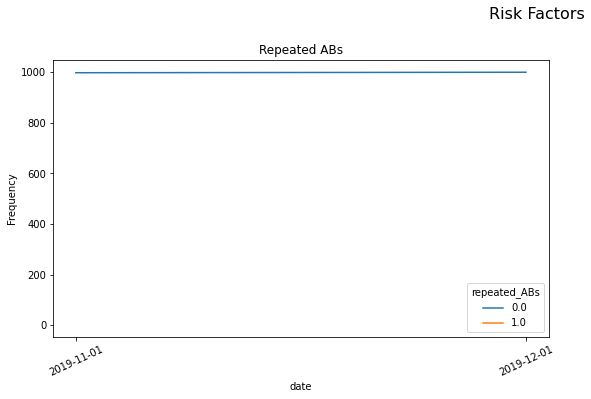

In [40]:
fig, axes = plt.subplots(2,2,
                        figsize=(15, 10)
                        )
create_lineplot('repeated_ABs', 'Repeated ABs', axes[0,0])
fig.delaxes(ax=axes[0,1])
fig.delaxes(ax=axes[1,0])
fig.delaxes(ax=axes[1,1])

fig.suptitle('Risk Factors', fontsize=16)
fig.tight_layout(rect=[0, 0.03, 1, 0.98])
#plt.xlim(2019-01-01, 2019-12-01)
#plt.tight_layout()
#plt.savefig('../output/hospitalisation_risk/risk_factors_cat.jpg')
plt.show()

0.0    1995
1.0       5
Name: repeated_ABs, dtype: int64


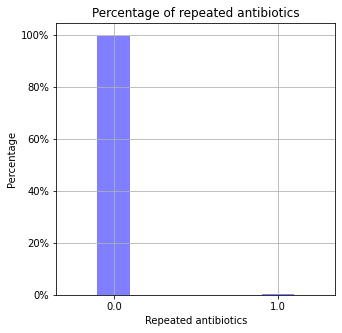

In [144]:
data['repeated_ABs'].value_counts(np.nan).sort_index().plot(kind='bar', figsize=(5, 5), rot=0, color = 'blue', alpha=0.5, width=0.2)
plt.xlabel('Repeated antibiotics')
plt.ylabel('Percentage')
plt.title('Percentage of repeated antibiotics')
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.grid()
print(data['repeated_ABs'].value_counts().sort_index())
#plt.savefig(r'../output/hospitalisation_risk/repeated_ABs.png', edgecolor='none')
plt.show()

## Cox model

In [83]:
data.columns

Index(['bmi_date_measured', 'smoking_status_date',
       'most_recent_unclear_smoking_cat_date', 'flu_vaccine_med',
       'flu_vaccine_clinical', 'sgss_positive', 'covrx1_dat', 'covrx2_dat',
       'died_date', 'uti_date_1', 'uti_ab_date_1', 'uti_date_2',
       'uti_ab_date_2', 'uti_date_3', 'uti_ab_date_3', 'uti_date_4',
       'uti_ab_date_4', 'lrti_date_1', 'lrti_ab_date_1', 'lrti_date_2',
       'lrti_ab_date_2', 'lrti_date_3', 'lrti_ab_date_3', 'lrti_date_4',
       'lrti_ab_date_4', 'age', 'age_cat', 'sex', 'practice', 'region', 'msoa',
       'imd', 'bmi', 'ethnicity', 'smoking_status', 'gp_count',
       'flu_vaccine_tpp', 'flu_vaccine', 'antibacterial_prescriptions',
       'antibacterial_brit', 'broad_spectrum_antibiotics_prescriptions',
       'primary_care_covid', 'admitted', 'uti_counts', 'lrti_counts',
       'urti_counts', 'sinusitis_counts', 'ot_externa_counts',
       'otmedia_counts', 'uti_pt', 'lrti_pt', 'urti_pt', 'sinusitis_pt',
       'ot_externa_pt', 'otmedia_

In [86]:
data['lrti_ab_date_4'].value_counts()

2021-01-06    3
2019-12-08    3
2019-02-20    2
2020-02-10    2
2019-04-09    2
             ..
2020-01-20    1
2021-11-23    1
2020-04-03    1
2021-08-25    1
2020-06-24    1
Name: lrti_ab_date_4, Length: 182, dtype: int64

In [112]:
data['uti_ab_date_1'] = pd.to_datetime(data['uti_ab_date_1'], format='%Y-%m-%d', errors='ignore')
data['uti_ab_date_2'] = pd.to_datetime(data['uti_ab_date_2'], format='%Y-%m-%d', errors='ignore')
data['uti_ab_date_3'] = pd.to_datetime(data['uti_ab_date_3'], format='%Y-%m-%d', errors='ignore')
data['uti_ab_date_4'] = pd.to_datetime(data['uti_ab_date_4'], format='%Y-%m-%d', errors='ignore')

data['lrti_ab_date_1'] = pd.to_datetime(data['lrti_ab_date_1'], format='%Y-%m-%d', errors='ignore')
data['lrti_ab_date_2'] = pd.to_datetime(data['lrti_ab_date_2'], format='%Y-%m-%d', errors='ignore')
data['lrti_ab_date_3'] = pd.to_datetime(data['lrti_ab_date_3'], format='%Y-%m-%d', errors='ignore')
data['lrti_ab_date_4'] = pd.to_datetime(data['lrti_ab_date_4'], format='%Y-%m-%d', errors='ignore')

In [89]:
data['repeated_ABs'] = np.nan
col0 = data.columns.get_loc('repeated_ABs')

col1 = data.columns.get_loc('uti_ab_date_1')
col2 = data.columns.get_loc('uti_ab_date_2')
col3 = data.columns.get_loc('uti_ab_date_3')
col4 = data.columns.get_loc('uti_ab_date_4')

col5 = data.columns.get_loc('lrti_ab_date_1')
col6 = data.columns.get_loc('lrti_ab_date_2')
col7 = data.columns.get_loc('lrti_ab_date_3')
col8 = data.columns.get_loc('lrti_ab_date_4')

In [91]:
y

[10, 12, 14, 16, 18, 20, 22, 24]

In [101]:
data.lrti_ab_date_4

0      NaT
1      NaT
2      NaT
3      NaT
4      NaT
        ..
1995   NaT
1996   NaT
1997   NaT
1998   NaT
1999   NaT
Name: lrti_ab_date_4, Length: 2000, dtype: datetime64[ns]

In [103]:
y = [col1, col2, col3, col4, col5, col6, col7, col8]
y = list(map(int, y))
y

[10, 12, 14, 16, 18, 20, 22, 24]

In [106]:
(data.iat[2,12]-data.iat[2,10]).days

nan

In [108]:
for idx, x in enumerate(data['repeated_ABs']):
    n=0
    for i in y:
        j=i+2
        if (data.iat[idx,j]-data.iat[idx,i]).days < 90:
            n=n+1
    data.iat[idx, col0]=n

TypeError: '<' not supported between instances of 'float' and 'str'

In [ ]:
for idx, x in enumerate(data['repeated_ABs']):
    n=0
    if data.iat[idx, col2] > 0:
        if data.iat[idx, col1] > 0:
            if (data.iat[idx,col6]-data.iat[idx,col5]).days > 30:
                n=n+1
    
    data.iat[idx, col0]=n

In [159]:
data['uti_date_1'] = pd.to_datetime(data['uti_date_1'], format='%Y-%m-%d', errors='ignore')
data['uti_date_2'] = pd.to_datetime(data['uti_date_2'], format='%Y-%m-%d', errors='ignore')
data['uti_date_3'] = pd.to_datetime(data['uti_date_3'], format='%Y-%m-%d', errors='ignore')
data['uti_date_4'] = pd.to_datetime(data['uti_date_4'], format='%Y-%m-%d', errors='ignore')

In [160]:
data['lrti_date_1'] = pd.to_datetime(data['lrti_date_1'], format='%Y-%m-%d', errors='ignore')
data['lrti_date_2'] = pd.to_datetime(data['lrti_date_2'], format='%Y-%m-%d', errors='ignore')
data['lrti_date_3'] = pd.to_datetime(data['lrti_date_3'], format='%Y-%m-%d', errors='ignore')
data['lrti_date_4'] = pd.to_datetime(data['lrti_date_4'], format='%Y-%m-%d', errors='ignore')

In [161]:
data['repeated_ABs'] = np.nan
col0 = data.columns.get_loc('repeated_ABs')

col1 = data.columns.get_loc('uti_ab_count_1')
col2 = data.columns.get_loc('uti_ab_count_2')
col3 = data.columns.get_loc('uti_ab_count_3')
col4 = data.columns.get_loc('uti_ab_count_4')

col5 = data.columns.get_loc('uti_date_1')
col6 = data.columns.get_loc('uti_date_2')
col7 = data.columns.get_loc('uti_date_3')
col8 = data.columns.get_loc('uti_date_4')

col9 = data.columns.get_loc('lrti_ab_count_1')
col10 = data.columns.get_loc('lrti_ab_count_2')
col11 = data.columns.get_loc('lrti_ab_count_3')
col12 = data.columns.get_loc('lrti_ab_count_4')

col13 = data.columns.get_loc('lrti_date_1')
col14 = data.columns.get_loc('lrti_date_2')
col15 = data.columns.get_loc('lrti_date_3')
col16 = data.columns.get_loc('lrti_date_4')

for idx, x in enumerate(data['repeated_ABs']):
    n=np.nan
    if data.iat[idx, col2] > 0:
        if data.iat[idx, col1] > 0:
            if (data.iat[idx,col6]-data.iat[idx,col5]).days < 90:
                n=(data.iat[idx,col6]-data.iat[idx,col5]).days
    if data.iat[idx, col3] > 0:
        if data.iat[idx, col2] > 0:
            if (data.iat[idx,col7]-data.iat[idx,col6]).days < 90:
                n=(data.iat[idx,col7]-data.iat[idx,col6]).days
    if data.iat[idx, col4] > 0:
        if data.iat[idx, col3] > 0:
            if (data.iat[idx,col8]-data.iat[idx,col7]).days < 90:
                n=(data.iat[idx,col8]-data.iat[idx,col7]).days

    if data.iat[idx, col1] > 0:
        if data.iat[idx, col9] > 0:
            if (data.iat[idx,col5]-data.iat[idx,col13]).days < 90:
                n=(data.iat[idx,col5]-data.iat[idx,col13]).days
    if data.iat[idx, col10] > 0:
        if data.iat[idx, col9] > 0:
            if (data.iat[idx,col14]-data.iat[idx,col13]).days < 90:
                n=(data.iat[idx,col14]-data.iat[idx,col13]).days
    if data.iat[idx, col11] > 0:
        if data.iat[idx, col10] > 0:
            if (data.iat[idx,col15]-data.iat[idx,col14]).days < 90:
                n=(data.iat[idx,col15]-data.iat[idx,col14]).days
    if data.iat[idx, col12] > 0:
        if data.iat[idx, col11] > 0:
            if (data.iat[idx,col16]-data.iat[idx,col15]).days < 90:
                n=(data.iat[idx,col16]-data.iat[idx,col15]).days
    
    data.iat[idx, col0]=n

In [ ]:
####### add -90 and try to get rid of big neg values


# data['repeated_ABs'] = np.nan
# col0 = data.columns.get_loc('repeated_ABs')

# col1 = data.columns.get_loc('uti_ab_count_1')
# col2 = data.columns.get_loc('uti_ab_count_2')
# col3 = data.columns.get_loc('uti_ab_count_3')
# col4 = data.columns.get_loc('uti_ab_count_4')

# col5 = data.columns.get_loc('uti_date_1')
# col6 = data.columns.get_loc('uti_date_2')
# col7 = data.columns.get_loc('uti_date_3')
# col8 = data.columns.get_loc('uti_date_4')

# col9 = data.columns.get_loc('lrti_ab_count_1')
# col10 = data.columns.get_loc('lrti_ab_count_2')
# col11 = data.columns.get_loc('lrti_ab_count_3')
# col12 = data.columns.get_loc('lrti_ab_count_4')

# col13 = data.columns.get_loc('lrti_date_1')
# col14 = data.columns.get_loc('lrti_date_2')
# col15 = data.columns.get_loc('lrti_date_3')
# col16 = data.columns.get_loc('lrti_date_4')

# for idx, x in enumerate(data['repeated_ABs']):
#     n=np.nan
#     if data.iat[idx, col2] > 0:
#         if data.iat[idx, col1] > 0:
#             if (data.iat[idx,col6]-data.iat[idx,col5]).days < 90:
#                 n=(data.iat[idx,col6]-data.iat[idx,col5]).days
#     if data.iat[idx, col3] > 0:
#         if data.iat[idx, col2] > 0:
#             if (data.iat[idx,col7]-data.iat[idx,col6]).days < 90:
#                 n=(data.iat[idx,col7]-data.iat[idx,col6]).days
#     if data.iat[idx, col4] > 0:
#         if data.iat[idx, col3] > 0:
#             if (data.iat[idx,col8]-data.iat[idx,col7]).days < 90:
#                 n=(data.iat[idx,col8]-data.iat[idx,col7]).days

#     if data.iat[idx, col1] > 0:
#         if data.iat[idx, col9] > 0:
#             if (data.iat[idx,col5]-data.iat[idx,col13]).days < 90:
#                 n=(data.iat[idx,col5]-data.iat[idx,col13]).days
#     if data.iat[idx, col10] > 0:
#         if data.iat[idx, col9] > 0:
#             if (data.iat[idx,col14]-data.iat[idx,col13]).days < 90:
#                 n=(data.iat[idx,col14]-data.iat[idx,col13]).days
#     if data.iat[idx, col11] > 0:
#         if data.iat[idx, col10] > 0:
#             if (data.iat[idx,col15]-data.iat[idx,col14]).days < 90:
#                 n=(data.iat[idx,col15]-data.iat[idx,col14]).days
#     if data.iat[idx, col12] > 0:
#         if data.iat[idx, col11] > 0:
#             if (data.iat[idx,col16]-data.iat[idx,col15]).days < 90:
#                 n=(data.iat[idx,col16]-data.iat[idx,col15]).days
    
#     data.iat[idx, col0]=n

In [162]:
data['repeated_ABs'].value_counts()

 2.0      2
 58.0     1
-848.0    1
-715.0    1
-6.0      1
-168.0    1
 35.0     1
-122.0    1
-814.0    1
-769.0    1
-586.0    1
-332.0    1
-275.0    1
 45.0     1
-563.0    1
 48.0     1
 84.0     1
Name: repeated_ABs, dtype: int64

In [165]:
data['repeated_ABs'] = data[data['repeated_ABs'] > -90]

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
         ..
11995   NaN
11996   NaN
11997   NaN
11998   NaN
11999   NaN
Name: repeated_ABs, Length: 12000, dtype: float64

## Questions:
- I expect all dates to be within the one month period that the input data is supposedly generated/collected. How it is justified to have a date of 2020 (e.g. UTI diagnosis), while the data belongs to 2019? Is it becuase of having dummy data?
- Is our focus on repeated ABs for just one specific infection or any repeated ABs for any infection (LRTI and UTI)?